In [1]:
import sys
sys.path.append('../../../Share')
import config, baseline, Target, Model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

In [ ]:
SUBJECT = "Hunmin"
baseline_K_val = [i for i in range(len(config.dataset_sub_H))]

ACC_lst = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    X_train, y_train = balance_data(X_train, y_train)

    X_test, y_test, _, _ = trainer.return_K_th_data_only(K+1, train_ratio=1)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    #print(pd.Series(y_test).value_counts())

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst.append(acc)
    print(ACC_lst, f"{i}/{len(baseline_K_val)}\n\n")
    pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Returning K-th session data: Exp_2025-06-20-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
Finish Training! (Model is NOT saved)

[0.6618427634239197] 0/66


Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Dataset 2/66 - Session Exp_2025-06-18/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-20-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
Finish Training! (Model is NOT saved)

[0.6618427634239197, 0.8506335020065308] 1/66


Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Dataset 2/66 - Session Exp_2025-06-18/E9AD0E7DCC2B/
Dataset 3/66 - Session Exp_2025-06-20-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-06-20-v3/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
Finish Training! (Model is NOT saved)

[0.6618427634239197, 0.8506335020065308, 0.8846801519393921] 2/66


Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Dataset 2/66 - Session Exp_2025-06-18/E9AD0E7DCC2B/
Dataset 3/66 - Session 

In [ ]:
[0.6618427634239197, 0.8506335020065308, 0.8846801519393921, 0.7390081882476807, 0.7105385065078735, 0.604519784450531, 0.7553143501281738, 0.8853018283843994, 0.8954712748527527, 0.7766666412353516, 0.884984016418457, 0.923701286315918, 0.883537232875824, 0.8426816463470459, 0.8330170512199402, 0.7911208271980286, 0.7804877758026123]


In [2]:
baseline_K_val = [i for i in range(len(config.dataset_sub_H))]
SUBJECT = "Hunmin"

ACC_lst_target = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, X_test, y_test = trainer.return_K_th_data_only(K, train_ratio=0.7)
    X_train, y_train = balance_data(X_train, y_train)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst_target.append(acc)
    print(ACC_lst_target, f"{i}/{len(baseline_K_val)}\n\n")
    #pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Returning K-th session data: Exp_2025-06-18/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.8333333134651184] 0/66


Returning K-th session data: Exp_2025-06-20-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.8333333134651184, 0.9622806906700134] 1/66


Returning K-th session data: Exp_2025-06-20-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.8333333134651184, 0.9622806906700134, 0.9331797361373901] 2/66


Returning K-th session data: Exp_2025-06-20-v3/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.8333333134651184, 0.9622806906700134, 0.9331797361373901, 0.942375898361206] 3/66


Returning K-th session data: Exp_2025-06-20-v4/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.8333333134651184, 0.9622806906700134, 0.9331797361373901, 0.942375898361206, 0.8905723690986633] 4/66


Returning K-th session data: Exp_2025-06-20-v5/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.8333333134651184, 0.9622806906700134, 0.9331797361373901, 0.94237589

In [3]:
SUBJECT = "Hunmin"
baseline_K_val = [i for i in range(len(config.dataset_sub_H))]

ACC_lst = []
for i, K in enumerate(baseline_K_val[50:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    X_train, y_train = balance_data(X_train, y_train)
    print(X_train.shape, y_train.shape)

    X_test, y_test, _, _ = trainer.return_K_th_data_only(K+1, train_ratio=1)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    #print(pd.Series(y_test).value_counts())

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst.append(acc)
    print(ACC_lst, f"{i}/{len(baseline_K_val)}\n\n")
    pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)

Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Dataset 2/66 - Session Exp_2025-06-18/E9AD0E7DCC2B/
Dataset 3/66 - Session Exp_2025-06-20-v1/E9AD0E7DCC2B/
Dataset 4/66 - Session Exp_2025-06-20-v2/E9AD0E7DCC2B/
Dataset 5/66 - Session Exp_2025-06-20-v3/E9AD0E7DCC2B/
Dataset 6/66 - Session Exp_2025-06-20-v4/E9AD0E7DCC2B/
Dataset 7/66 - Session Exp_2025-06-20-v5/E9AD0E7DCC2B/
Dataset 8/66 - Session Exp_2025-06-20-v6/E9AD0E7DCC2B/
Dataset 9/66 - Session Exp_2025-06-20-v7/E9AD0E7DCC2B/
Dataset 10/66 - Session Exp_2025-06-20-v8/E9AD0E7DCC2B/
Dataset 11/66 - Session Exp_2025-06-23-v1/E9AD0E7DCC2B/
Dataset 12/66 - Session Exp_2025-06-23-v2/E9AD0E7DCC2B/
Dataset 13/66 - Session Exp_2025-06-23-v3/E9AD0E7DCC2B/
Dataset 14/66 - Session Exp_2025-06-23-v4/E9AD0E7DCC2B/
Dataset 15/66 - Session Exp_2025-06-24-v1/E9AD0E7DCC2B/
Dataset 16/66 - Session Exp_2025-06-24-v2/E9AD0E7DCC2B/
Dataset 17/66 - Session Exp_2025-06-24-v3/E9AD0E7DCC2B/
Dataset 18/66 - Session Exp_2025-06-24-v4/E9AD0E7DCC2B/
Dataset


KeyboardInterrupt



Dataset 1/66 - Session Exp_2025-05-27/E8331D05289A/
Dataset 2/66 - Session Exp_2025-06-18/E9AD0E7DCC2B/
Dataset 3/66 - Session Exp_2025-06-20-v1/E9AD0E7DCC2B/
Dataset 4/66 - Session Exp_2025-06-20-v2/E9AD0E7DCC2B/
Dataset 5/66 - Session Exp_2025-06-20-v3/E9AD0E7DCC2B/
Dataset 6/66 - Session Exp_2025-06-20-v4/E9AD0E7DCC2B/
Dataset 7/66 - Session Exp_2025-06-20-v5/E9AD0E7DCC2B/
Dataset 8/66 - Session Exp_2025-06-20-v6/E9AD0E7DCC2B/
Dataset 9/66 - Session Exp_2025-06-20-v7/E9AD0E7DCC2B/
Dataset 10/66 - Session Exp_2025-06-20-v8/E9AD0E7DCC2B/
Dataset 11/66 - Session Exp_2025-06-23-v1/E9AD0E7DCC2B/
Dataset 12/66 - Session Exp_2025-06-23-v2/E9AD0E7DCC2B/
Dataset 13/66 - Session Exp_2025-06-23-v3/E9AD0E7DCC2B/
Dataset 14/66 - Session Exp_2025-06-23-v4/E9AD0E7DCC2B/
Dataset 15/66 - Session Exp_2025-06-24-v1/E9AD0E7DCC2B/
Dataset 16/66 - Session Exp_2025-06-24-v2/E9AD0E7DCC2B/
Dataset 17/66 - Session Exp_2025-06-24-v3/E9AD0E7DCC2B/
Dataset 18/66 - Session Exp_2025-06-24-v4/E9AD0E7DCC2B/
Dataset

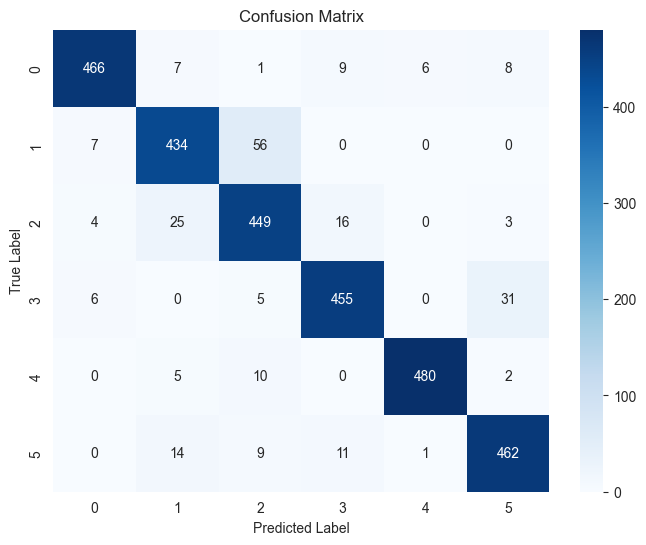

In [2]:
baseline_K_val = [i for i in range(len(config.dataset_sub_H))]
SUBJECT = "Hunmin"

from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow import keras


def heatmap_confusion_matrix(X_test, y_test, model):
    # Predict class labels on the test set
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)  # convert softmax probs to predicted class
    y_true = y_test
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(np.max(y_test)+1), yticklabels=range(np.max(y_test)+1))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    return cm


for i, K in enumerate([baseline_K_val[20:45]]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    X_train, y_train = balance_data(X_train, y_train)

    X_test, y_test, _, _ = trainer.return_K_th_data_only(K+1, train_ratio=1)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    history, _ =  Model.Train_model(model, X_train, y_train, X_test, y_test, set_epoch=100, set_batch_size=128, Model_name=f'{SUBJECT}_best_model', set_verbose=False, save_model_set=True)

    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print(acc)

    model_best = keras.models.load_model(f'{SUBJECT}_best_model.keras')

    acc = model_best.evaluate(X_test, y_test, verbose=0)[1]
    print(acc)

    cm = heatmap_confusion_matrix(X_test, y_test, model)

In [3]:
cm.tolist()

[[466, 7, 1, 9, 6, 8],
 [7, 434, 56, 0, 0, 0],
 [4, 25, 449, 16, 0, 3],
 [6, 0, 5, 455, 0, 31],
 [0, 5, 10, 0, 480, 2],
 [0, 14, 9, 11, 1, 462]]

In [4]:
CM =[[466, 7, 1, 9, 6, 8],
 [7, 434, 56, 0, 0, 0],
 [4, 25, 449, 16, 0, 3],
 [6, 0, 5, 455, 0, 31],
 [0, 5, 10, 0, 480, 2],
 [0, 14, 9, 11, 1, 462]]

accuracy = np.trace(CM) / np.sum(CM)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Overall Accuracy: 0.9209 (92.09%)
